# Recommending agents the way the pros pick them: development

Win prediction reached 54.5% on unseen maps (notebook 12): honest, but not a headline. The
headline is a **recommender**: give it a map and any agents already locked in, and it
suggests the rest, the way professional teams actually pick. It never claims its picks win,
because agent picks don't predict the winner.

**How it's measured**, on line-ups it has never seen:

1. **Complete a line-up.** Hide one agent from a real pro line-up, give it the map and the
   other four, and see where it ranks the hidden agent. **Top-1**: first suggestion. **Top-3**:
   among the first three. Each line-up is asked five times, once per hidden agent.
2. **From scratch.** Give it only the map, let it build all five, and count how many the pros
   actually played.

**The bar** is a naive rule, *the most-played agents on this map lately*. With four locked in,
about 23 agents are left, so random guessing gets top-3 about 13% of the time.

**Development only:** it learns from 2024 and is scored on 2025 up to Masters Toronto. The
test half is untouched.

## The rules, set before any result below

- **Week by week.** Each week is recommended from line-ups played *before* it, as the tool
  would be used. New agents (Tejo, Vyse, Waylay) and a new map (Corrode) are picked up as pros
  start playing them.
- **Methods**, from [`src/recommend.py`](../src/recommend.py):
  - *Popularity*: the naive rule.
  - *Co-occurrence*: the same count, but a past line-up gets ten times more say for each
    locked agent it shares.
  - *Classifier*: logistic regression predicting the missing agent from the map and the locked
    agents.
- **Recency:** each method is tried with no fading and half-lives of 365, 180, 90, 45, 21, 14
  and 7 days, and keeps its best. The naive rule gets the same chance.
- **The headline is the non-naive method with the best top-3**, fixed in the test notebook
  before it runs.

**Added after the first results, at the user's request:** two models that can learn that the
same agents lead to different picks on different maps: the classifier with a column for every
map-and-agent pair, and gradient boosting (`HistGradientBoostingClassifier`, default settings).
Gradient boosting is about 40 times slower, so it gets only 21, 45 and 90 days. Adding methods
after seeing results is one more chance to fit this data by luck, which is why the test is
fixed in advance and run once.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))

pd.set_option("display.width", 200)

from sklearn.ensemble import HistGradientBoostingClassifier

from dataset import build_map_table, split_season
from recommend import (Classifier, CoOccurrence, Popularity, build_from_scratch, lineup_table,
                       rank_of, summarise, walk_forward)

INK, MUTED, RULE = "#2A3038", "#5A6570", "#D5DAE0"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": RULE, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RULE, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})

## 1. The line-ups

In [2]:
history = lineup_table(build_map_table("vct_2024"))
learn_2025, _ = split_season(build_map_table())       # the test half is not used here
dev = lineup_table(learn_2025)

print(f"learned from : {len(history):,} line-ups, all of 2024 ({history.played_at.min():%d %b} - {history.played_at.max():%d %b %Y})")
print(f"scored on    : {len(dev):,} line-ups, 2025 up to Masters Toronto, over "
      f"{dev.played_at.dt.to_period('W').nunique()} weeks")
print(f"               x 5 hidden agents = {len(dev) * 5:,} complete-a-line-up questions")

known_2024 = {a for lineup in history.agents for a in lineup}
debut = {}
for when, lineup in zip(dev.played_at, dev.agents):
    for a in lineup:
        if a not in known_2024:
            debut.setdefault(a, when)
print("\nagents never seen in 2024, and their first 2025 appearance:")
for a, when in sorted(debut.items(), key=lambda kv: kv[1]):
    print(f"   {a:8} {when:%d %b}")

learned from : 2,208 line-ups, all of 2024 (17 Feb - 25 Aug 2024)
scored on    : 1,512 line-ups, 2025 up to Masters Toronto, over 20 weeks
               x 5 hidden agents = 7,560 complete-a-line-up questions

agents never seen in 2024, and their first 2025 appearance:
   vyse     11 Jan
   tejo     16 Jan
   waylay   13 Mar


## 2. Checking the scoring

**Ties count against the recommender**, and **an agent a method has never seen counts as a
miss**, not skipped.

In [3]:
scores = pd.Series({"viper": 3.0, "sova": 2.0, "kayo": 2.0, "jett": 1.0})
assert rank_of(scores, [], "viper") == 1
assert rank_of(scores, [], "sova") == 2 + 1          # level with kayo, so it takes the worse rank
assert rank_of(scores, ["viper"], "kayo") == 2       # locked agents are not candidates
assert rank_of(scores, [], "tejo") == np.inf         # never seen -> a miss
print("scoring checks pass")

# And on real data: with nothing locked in, co-occurrence must agree with popularity exactly.
as_of = dev.played_at.min().normalize()
pop, co = Popularity().fit(history, as_of), CoOccurrence().fit(history, as_of)
for m in history["map"].unique():
    assert pop.scores(m).idxmax() == co.scores(m).idxmax()
print("with nothing locked in, co-occurrence and popularity give the same top pick on every map")

scoring checks pass
with nothing locked in, co-occurrence and popularity give the same top pick on every map


## 3. Every method, at every recency setting

Each run refits every week for 20 weeks; this cell takes about an hour.

In [4]:
HALF_LIVES = [None, 365, 180, 90, 45, 21, 14, 7]
BOOSTED_HALF_LIVES = [90, 45, 21]          # narrowed -- see the rules above

METHODS = {
    "popularity (naive rule)": (lambda h: Popularity(h), HALF_LIVES),
    "co-occurrence": (lambda h: CoOccurrence(h), HALF_LIVES),
    "classifier": (lambda h: Classifier(h), HALF_LIVES),
    "classifier + map x agent": (lambda h: Classifier(h, interactions=True), HALF_LIVES),
    "gradient boosting": (lambda h: Classifier(h, estimator=HistGradientBoostingClassifier(random_state=0)),
                          BOOSTED_HALF_LIVES),
}

runs, rows = {}, []
for method, (make, half_lives) in METHODS.items():
    for half_life in half_lives:
        result = walk_forward(history, dev, lambda: make(half_life))
        runs[(method, half_life)] = result
        rows.append({"method": method, "half-life (days)": "none" if half_life is None else half_life,
                     **summarise(result)})

sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, formatters={"top-1": "{:.1%}".format, "top-3": "{:.1%}".format,
                                               "from scratch, of 5": "{:.2f}".format}))

                  method half-life (days) top-1 top-3 from scratch, of 5
 popularity (naive rule)             none 43.0% 62.1%               2.93
 popularity (naive rule)              365 43.5% 63.0%               2.97
 popularity (naive rule)              180 44.3% 65.0%               3.04
 popularity (naive rule)               90 44.7% 67.6%               3.11
 popularity (naive rule)               45 45.9% 69.2%               3.16
 popularity (naive rule)               21 47.3% 70.1%               3.22
 popularity (naive rule)               14 48.1% 70.3%               3.24
 popularity (naive rule)                7 48.9% 71.1%               3.26
           co-occurrence             none 64.5% 81.8%               2.88
           co-occurrence              365 65.6% 83.4%               2.88
           co-occurrence              180 66.9% 84.7%               2.89
           co-occurrence               90 68.2% 86.1%               2.95
           co-occurrence               45 69.2% 86.

In [5]:
best = sweep.loc[sweep.groupby("method", sort=False)["top-3"].idxmax()].set_index("method")
print("each method at its best half-life, by top-3:\n")
print(best.to_string(formatters={"top-1": "{:.1%}".format, "top-3": "{:.1%}".format,
                                 "from scratch, of 5": "{:.2f}".format}))

contenders = best.drop(index="popularity (naive rule)")

def half_life_of(method):
    h = best.loc[method, "half-life (days)"]
    return None if h == "none" else h
headline = contenders["top-3"].idxmax()
print(f"\nheadline method, by the rule set above: {headline} "
      f"(half-life {contenders.loc[headline, 'half-life (days)']})")

each method at its best half-life, by top-3:

                         half-life (days) top-1 top-3 from scratch, of 5
method                                                                  
popularity (naive rule)                 7 48.9% 71.1%               3.26
co-occurrence                          21 69.2% 86.7%               3.17
classifier                             45 65.6% 86.1%               3.12
classifier + map x agent               21 68.5% 87.6%               3.11
gradient boosting                      45 68.2% 88.0%               3.11

headline method, by the rule set above: gradient boosting (half-life 45)


### Are the gaps between the leaders real?

The top three finish within about a point. Resampling whole matches shows which gaps would
survive a different run of weeks. Every method answers the same questions, so the comparison
is paired.

In [6]:
def per_lineup(result, cutoff):
    ranks = np.vstack(result["ranks"].to_numpy())
    return (ranks <= cutoff).mean(axis=1)

leaders = {m: runs[(m, half_life_of(m))] for m in contenders.sort_values("top-3", ascending=False).index[:3]}
top_name = next(iter(leaders))
match_of = leaders[top_name]["match_id"].to_numpy()
match_ids = np.unique(match_of)
rows_of = {m: np.flatnonzero(match_of == m) for m in match_ids}
rng = np.random.default_rng(0)
draws = [np.concatenate([rows_of[m] for m in rng.choice(match_ids, len(match_ids))]) for _ in range(3000)]

print(f"{top_name} minus each of the others, in points (95% range from resampling matches):\n")
for other in list(leaders)[1:]:
    for label, cutoff in [("top-3", 3), ("top-1", 1)]:
        a, b = per_lineup(leaders[top_name], cutoff), per_lineup(leaders[other], cutoff)
        diffs = np.array([a[d].mean() - b[d].mean() for d in draws]) * 100
        lo, hi = np.percentile(diffs, [2.5, 97.5])
        print(f"   vs {other:26} {label}: {(a.mean() - b.mean()) * 100:+.1f}   ({lo:+.1f} to {hi:+.1f})")

gradient boosting minus each of the others, in points (95% range from resampling matches):

   vs classifier + map x agent   top-3: +0.4   (-0.2 to +1.0)
   vs classifier + map x agent   top-1: -0.3   (-1.3 to +0.6)
   vs co-occurrence              top-3: +1.3   (+0.5 to +2.2)
   vs co-occurrence              top-1: -1.0   (-1.8 to -0.2)


## 4. Week by week

An average can hide a method that collapses when the game changes. Dashed lines mark each new
agent's first week.

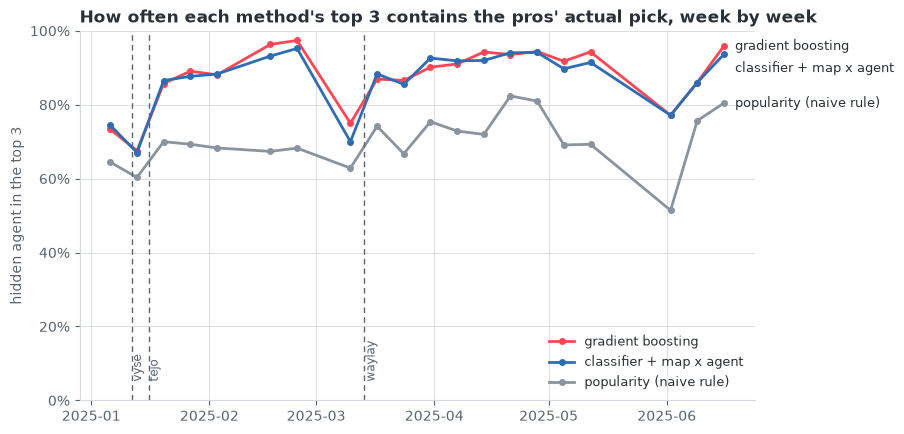

In [7]:
# Three lines, not five: the headline, the best of the other models, and the naive rule.
runner_up = contenders.drop(index=headline)["top-3"].idxmax()
colours = {headline: "#FF4655", runner_up: "#2E6DB4", "popularity (naive rule)": "#8A949E"}
fig, ax = plt.subplots(figsize=(10, 4.8))
ends = []
for method, colour in colours.items():
    r = runs[(method, half_life_of(method))]
    weekly = r.groupby("week")["ranks"].apply(lambda rs: (np.concatenate(rs.to_numpy()) <= 3).mean())
    ax.plot(weekly.index, weekly.values, color=colour, lw=2, marker="o", ms=4, label=method)
    ends.append([weekly.values[-1], method, weekly.index[-1]])
ends.sort(reverse=True)                      # top to bottom, then push apart any that crowd
for i in range(1, len(ends)):
    ends[i][0] = min(ends[i][0], ends[i - 1][0] - 0.06)
for y, method, x in ends:
    ax.annotate(method, (x, y), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color=INK)
for agent, when in debut.items():
    ax.axvline(when, color=MUTED, lw=1, ls=(0, (4, 3)))
    ax.text(when, 0.04, f" {agent}", color=MUTED, fontsize=8.5, rotation=90, va="bottom")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylabel("hidden agent in the top 3")
ax.set_title("How often each method's top 3 contains the pros' actual pick, week by week", loc="left")
ax.legend(loc="lower right", frameon=False, fontsize=9)
fig.subplots_adjust(right=0.8)
plt.show()

## 5. What a recommendation looks like

Real questions, answered by the headline method using everything up to Masters Toronto.

In [8]:
everything = pd.concat([history, dev], ignore_index=True)
as_of = dev.played_at.max().normalize() + pd.Timedelta(days=1)
model = METHODS[headline][0](half_life_of(headline)).fit(everything, as_of)

def show(map_name, locked):
    top = model.scores(map_name, locked).drop(locked, errors="ignore")
    top = top / top.sum()
    locked_text = ", ".join(locked) if locked else "nothing"
    picks = "   ".join(f"{a} {s:.0%}" for a, s in top.nlargest(3).items())
    print(f"{map_name:8} with {locked_text:34} ->  {picks}")

show("Icebox", ["viper", "sova", "killjoy", "jett"])
show("Lotus", ["omen", "fade", "raze"])
show("Haven", ["omen"])
show("Split", [])
print()
for m in ["Icebox", "Lotus", "Haven", "Split"]:
    print(f"built from scratch on {m:7}: {', '.join(build_from_scratch(model, m))}")

Icebox   with viper, sova, killjoy, jett         ->  harbor 39%   omen 19%   gekko 17%
Lotus    with omen, fade, raze                   ->  viper 30%   vyse 30%   killjoy 19%
Haven    with omen                               ->  sova 20%   yoru 15%   breach 12%
Split    with nothing                            ->  viper 18%   omen 16%   yoru 11%

built from scratch on Icebox : viper, killjoy, jett, harbor, sova


built from scratch on Lotus  : omen, viper, raze, fade, killjoy
built from scratch on Haven  : omen, sova, iso, cypher, yoru
built from scratch on Split  : viper, omen, yoru, breach, tejo


*The percentages share the method's scores among the agents not yet chosen: how strongly it
prefers each one, not a win chance.*

## What this notebook found

| Method, at its best recency | Top-1 | Top-3 | From scratch |
|---|---|---|---|
| Popularity: the naive rule (7 days) | 48.9% | 71.1% | 3.26 of 5 |
| Co-occurrence (21 days) | **69.2%** | 86.7% | 3.17 of 5 |
| Classifier (45 days) | 65.6% | 86.1% | 3.12 of 5 |
| Classifier + map × agent (21 days) | 68.5% | 87.6% | 3.11 of 5 |
| **Gradient boosting (45 days)** | 68.2% | **88.0%** | 3.11 of 5 |

1. **With four locked in, the best methods have the pros' pick in their top three about 88% of
   the time**, about 17 points above the naive rule, and name it first 68–69% of the time.
2. **Map-and-agent combinations help:** giving the classifier a column per pair added about
   1.5 points of top-3 (range +0.8 to +2.3, checked 22 September). Gradient boosting learns them by itself and did as well.
3. **Gradient boosting is the headline, by the rule set in advance.** It ties the map × agent
   classifier, and trades off against co-occurrence: more often in the top three (+1.3,
   range +0.5 to +2.2), less often first (−1.0, range −1.8 to −0.2). The user kept to the rule.
4. **Recency helps every method.**
5. **The naive rule's bar isn't set low.** Its best is at 7 days, the shortest tried; a later
   check (22 September) found nothing higher at 5, 3, 2 or 1 days (71.1% at best).
6. **From scratch, nothing beats the naive rule** (about 3.1–3.3 of five). **The value is in
   completing a line-up, not building one.**
7. **It adapts to new agents within a week or two**: accuracy dips the week Waylay arrives,
   then recovers.

**Cautions:** the recency settings and the headline were chosen on these numbers, and two
methods were added after the first results, so these figures are optimistic, like the win
model's 61.1%. The test is the real number. And matching the pros isn't winning.

**Fixed here for the test, before it's written or run:** gradient boosting at 45 days
(`random_state=0`) as the headline; the others reported at their best half-lives; history of
2024 plus 2025 up to Masters Toronto, then week by week through the test half; top-1, top-3
and from scratch, with 95% ranges from resampling whole matches.